In [47]:
import pandas as pd
import numpy as np
import pandas as pd
from collections import Counter
import math
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import cross_val_score
from sklearn.tree import export_text
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# Phase 3 - Machine Learning

In [48]:
def read_any(path):
    try:
        return pd.read_csv(path, sep=None, engine="python", encoding="utf-8-sig")
    except Exception:
        return pd.read_csv(path, sep=";", engine="python", encoding="utf-8-sig")

train = read_any("data/train_preprocessed.csv")
val = read_any("data/val_preprocessed.csv")
test = read_any("data/test_preprocessed.csv")

In [49]:
y_train = train["oximetry"]
X_train = train.drop(columns=["oximetry"])

y_val = val["oximetry"]
X_val = val.drop(columns=["oximetry"])

y_test = test["oximetry"]
X_test = test.drop(columns=["oximetry"])

## 3.1 Simple classifier based on data dependencies 

As it is required in this section, we will implement an ID3 classifier with depth >= 2. As it is typical for an ID3 classifier, we will build the different part of it using differnt functions and structures in order to correctly model the nodes, and define the algorithm which will create the tree. Moroever, we will define as well the criteria to split nodes as well.

# A

In [50]:
train.head()

,RR,EtCO₂,FiO₂,BP,Skin Temperature,oximetry
0,0.235464,1.261957,-0.633126,1.547414,-0.857641,1.0
1,0.093042,1.777442,-1.149314,-0.777152,1.116038,1.0
2,-0.889608,0.690601,-0.461918,0.109318,0.282559,1.0
3,1.482211,0.991076,-0.573146,0.986452,-1.249359,1.0
4,-0.358248,1.317829,-0.959410,-1.560852,1.015945,1.0


As we can see in the previous cell, this is an example of the data remaining after the EDA and preprocessing. The only cols remaining are RR, ETCO2, FIO2, BP and Skin Temperature, which turned out to be the only capable of explaining our target variable.

In [51]:
def entropy_from_counts(count_pos, count_neg):
    total = count_pos + count_neg
    if total == 0:
        return 0.0
    p_pos = count_pos / total
    p_neg = 1 - p_pos
    ent = 0.0
    if p_pos > 0:
        ent -= p_pos * math.log2(p_pos)
    if p_neg > 0:
        ent -= p_neg * math.log2(p_neg)
    return ent

This function is support function which  calculates the entropy of each a node taking into account the two target classes (oximetry 1 and 0). This will be used to calculate the Innformation Gain of a split of a certaind node into subnodes.

In [52]:
def best_split_for_feature(x_col, y_col):
    order = np.argsort(x_col) #we sort by x
    xs = x_col[order]
    ys = y_col[order]
    total_pos = int((ys == 1).sum())
    total_neg = int((ys == 0).sum())
    parent_entropy = entropy_from_counts(total_pos, total_neg)
    best_gain = 0.0
    best_thresh = None

    # consider thresholds where label changes between consecutive sorted samples
    for i in range(len(xs) - 1):
        if ys[i] == ys[i+1]:
            continue
        # candidate threshold = midpoint
        thresh = (xs[i] + xs[i+1]) / 2.0
        # left counts
        left_pos = int((ys[:i+1] == 1).sum())
        left_neg = int((ys[:i+1] == 0).sum())
        right_pos = total_pos - left_pos
        right_neg = total_neg - left_neg

        left_entropy = entropy_from_counts(left_pos, left_neg)
        right_entropy = entropy_from_counts(right_pos, right_neg)

        n = len(xs)
        gain = parent_entropy - ((i+1)/n)*left_entropy - ((n-(i+1))/n)*right_entropy
        if gain > best_gain:
            best_gain = gain
            best_thresh = thresh

    return best_gain, best_thresh


This a very important function, that is suportive of the main algorithm as well, which calculates the best split for a certain feature. There a few important things to comment in this part. 
- How are the thresholds defined? We first sort x column and define candidate thresholds in the midpoints where consecutive samples have a different target value. This allows us to have different candidate tresholds which together represent very well the different possibilities to partitionate the node. This gives us high probability to find a good thresolhs for this feature.
- How is Information Gain calculated? It is calculated with its common formula, calculating entropy of the parent and deducting normalized node splits entropies.

In [53]:
def best_split(X_node, y_node, feature_names):
    best_feat = None
    best_thresh = None
    best_gain = 0.0
    for j, fname in enumerate(feature_names):
        gain, thresh = best_split_for_feature(X_node[:, j], y_node)
        if gain > best_gain:
            best_gain = gain
            best_thresh = thresh
            best_feat = j
    return best_feat, best_thresh, best_gain

Here we have the function which uses the previous functions to calculate the best split possible in the dataset. The split returned in this function is the final split which will be performed and constated in the tree. To give the best split, we calculate the best possible split for each feature using the previous function and select the best from this. 

In [54]:
class Node:
    def __init__(self, depth=0):
        self.is_leaf = False
        self.pred = None
        self.probs = None
        self.feature = None
        self.threshold = None
        self.left = None
        self.right = None
        self.depth = depth
        self.n_samples = 0

In [55]:
def build_tree(X, y, feature_names, depth=0, max_depth=2, min_samples_split=5, min_gain=1e-6):
    node = Node(depth=depth)
    node.n_samples = len(y)
    cnt = Counter(y)
    pos = cnt.get(1, 0)
    neg = cnt.get(0, 0)
    node.pred = 1 if pos >= neg else 0
    node.probs = {0: neg / (pos + neg), 1: pos / (pos + neg)}

    if depth >= max_depth or len(y) < min_samples_split or pos == 0 or neg == 0:
        node.is_leaf = True
        return node

    feat_idx, thresh, gain = best_split(X, y, feature_names)
    if feat_idx is None or gain <= min_gain:
        node.is_leaf = True
        return node

    node.feature = feat_idx
    node.threshold = thresh
    left_mask = X[:, feat_idx] <= thresh
    right_mask = ~left_mask

    node.left = build_tree(X[left_mask], y[left_mask], feature_names, depth+1, max_depth, min_samples_split, min_gain)
    node.right = build_tree(X[right_mask], y[right_mask], feature_names, depth+1, max_depth, min_samples_split, min_gain)
    return node

Here we have the main algorithm for our ID3 classifier. This function builds the tree model which we will use to train and predict on our data. To build the three there are some things to comment:
- This functions compute a tree of several depths. Each depth has nodes. The top node is a all the dataset without splits. From it, the functions calculates the best split using the previous functions. With this split is performed, the algorithm keeps calculating splits for the nodes created recursively till some of the stopping conditions are met.
- Stopping conditions: We stop if we have reached the maximum depth defined, if the node has less samples than the minimum required or if some node only have positive or negative samples.

# B

Once we have all the ID3 classifier built, it is time to train and validate the models.

In [56]:
def predict_one(node, x):
    while not node.is_leaf:
        if x[node.feature] <= node.threshold:
            node = node.left
        else:
            node = node.right
    return node.pred

In [57]:
def predict(node, X):
    return np.array([predict_one(node, x) for x in X])

In [58]:
feature_names = list(X_train.columns)
Xtr = X_train.values
ytr = y_train.values.astype(int)
Xv = X_val.values
yv = y_val.values.astype(int)

max_depth = 2
tree = build_tree(Xtr, ytr, feature_names, max_depth=max_depth, min_samples_split=10)

ypred_val = predict(tree, Xv)

We have performed the training succesfully, so we'll evalute the results using the metrics library, which gives us accuracy, precision and recall metrics directly. Moreover, we have decided to calculate f1 score in order to compare metrics.

In [59]:
acc = metrics.accuracy_score(yv, ypred_val)
prec = metrics.precision_score(yv, ypred_val, zero_division=0)
rec = metrics.recall_score(yv, ypred_val, zero_division=0)
f1 = metrics.f1_score(yv, ypred_val, zero_division=0)
print(f"Val — acc:{acc:.3f} prec:{prec:.3f} rec:{rec:.3f} f1:{f1:.3f}")

Val — acc:0.808 prec:0.928 rec:0.734 f1:0.820


This are the results obtained with a simple ID3 classifier with max_depth = 2. Although it seems that our results are really good, we need to analyze each metric separetly.

Before commenting the metrics, we have to take into account that in our project is it worse to get a false negative than a false positive. For this reason, we need a metric which takes this into account, not all the metrics are suitable for our case.
- Accuracy : 0.808 -> This is a solid result in accuracy. However, we son't want to use this metric because our dataset is slightly imbalanced and it is worse to have a false negative than a false positive.
- Precision : 0.928 -> This is the best value among all metrics. However, it is not of our interest because precision penalizes false positives. Instead, we'd like to penalize false negatives, in order to fet the minimum number of false negative possible.
- Recall : 0.734 -> This metric is the metric of our interest. Recall penalizes false negatives, which is exactly what we want to do. Even though it is the lower value among all metrics, is the value which evalutes the best our model, se we will base our results on this metric.
- F1 score: 0.829 -> It is a pretty good result but, as already commentes, we want to use recall to evalute in order to penalize false negatives.

# C

In order ceck if there is overfitting, we will compare the results in the training and validation set, once the tree is generated.

In [60]:
max_depth = 2
tree = build_tree(Xtr, ytr, feature_names, max_depth=max_depth, min_samples_split=10)

# get predictions on train + val
ypred_train = predict(tree, Xtr)
ypred_val   = predict(tree, Xv)

acc_train = metrics.accuracy_score(ytr, ypred_train)
prec_train = metrics.precision_score(ytr, ypred_train, zero_division=0)
rec_train = metrics.recall_score(ytr, ypred_train, zero_division=0)
f1_train = metrics.f1_score(ytr, ypred_train, zero_division=0)
print(f"Train — acc:{acc_train:.3f} prec:{prec_train:.3f} rec:{rec_train:.3f} f1:{f1_train:.3f}")

acc_val = metrics.accuracy_score(yv, ypred_val)
prec_val = metrics.precision_score(yv, ypred_val, zero_division=0)
rec_val = metrics.recall_score(yv, ypred_val, zero_division=0)
f1_val = metrics.f1_score(yv, ypred_val, zero_division=0)
print(f"Val — acc:{acc_val:.3f} prec:{prec_val:.3f} rec:{rec_val:.3f} f1:{f1_val:.3f}")

Train — acc:0.812 prec:0.928 rec:0.741 f1:0.824
Val — acc:0.808 prec:0.928 rec:0.734 f1:0.820


As we can see in the results, our simple model does not present overfitting, as the training metrics are only a little bit higher (not really much) than the validation metrics.

However, this are the results of our tree with maximum_depth = 2. When deciding which maximum depth to use for out three, we found out that results are different for different maximum depths. For this reason, we have decided to plot accuracy, precision, recall and f1 score for different values of max_depth. In particular, we have plotted the results from maximum depth 1 to 21.

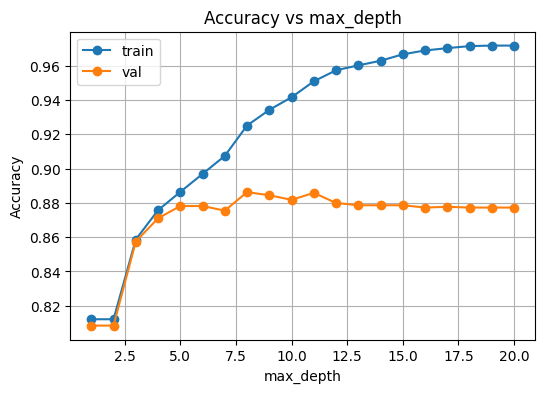

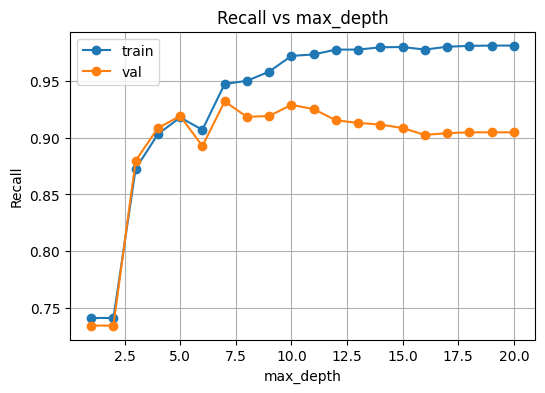

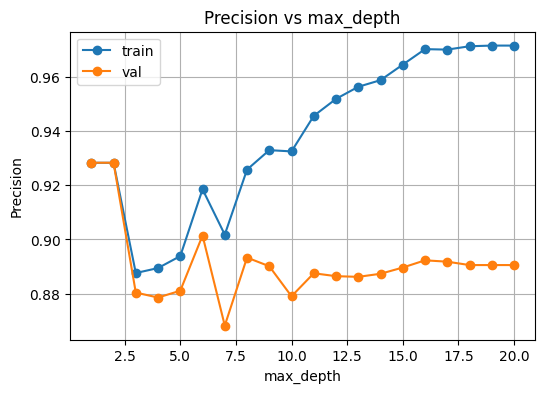

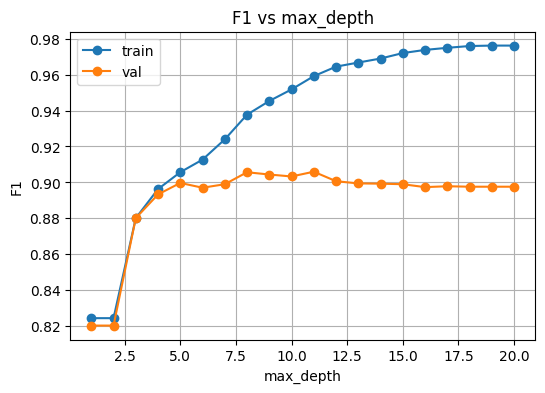

In [61]:
depths = list(range(1, 21))

acc_train_list, acc_val_list = [], []
prec_train_list, prec_val_list = [], []
rec_train_list, rec_val_list = [], []
f1_train_list, f1_val_list = [], []

for d in depths:
    tree = build_tree(Xtr, ytr, feature_names, max_depth=d, min_samples_split=10)

    ypred_train = predict(tree, Xtr)
    ypred_val   = predict(tree, Xv)

    acc_train = metrics.accuracy_score(ytr, ypred_train)
    prec_train = metrics.precision_score(ytr, ypred_train, zero_division=0)
    rec_train = metrics.recall_score(ytr, ypred_train, zero_division=0)
    f1_train = metrics.f1_score(ytr, ypred_train, zero_division=0)

    acc_val = metrics.accuracy_score(yv, ypred_val)
    prec_val = metrics.precision_score(yv, ypred_val, zero_division=0)
    rec_val = metrics.recall_score(yv, ypred_val, zero_division=0)
    f1_val = metrics.f1_score(yv, ypred_val, zero_division=0)

    acc_train_list.append(acc_train); acc_val_list.append(acc_val)
    prec_train_list.append(prec_train); prec_val_list.append(prec_val)
    rec_train_list.append(rec_train); rec_val_list.append(rec_val)
    f1_train_list.append(f1_train); f1_val_list.append(f1_val)

plt.figure(figsize=(6,4))
plt.plot(depths, acc_train_list, marker='o', label='train')
plt.plot(depths, acc_val_list, marker='o', label='val')
plt.xlabel('max_depth'); plt.ylabel('Accuracy'); plt.title('Accuracy vs max_depth')
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(6,4))
plt.plot(depths, rec_train_list, marker='o', label='train')
plt.plot(depths, rec_val_list, marker='o', label='val')
plt.xlabel('max_depth'); plt.ylabel('Recall'); plt.title('Recall vs max_depth')
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(6,4))
plt.plot(depths, prec_train_list, marker='o', label='train')
plt.plot(depths, prec_val_list, marker='o', label='val')
plt.xlabel('max_depth'); plt.ylabel('Precision'); plt.title('Precision vs max_depth')
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(6,4))
plt.plot(depths, f1_train_list, marker='o', label='train')
plt.plot(depths, f1_val_list, marker='o', label='val')
plt.xlabel('max_depth'); plt.ylabel('F1'); plt.title('F1 vs max_depth')
plt.legend(); plt.grid(True); plt.show()

We can see in the plots a clear pattern of overfitting. From 1 to 5 maximum_depth, we don't see signs of overfitting: training and evaluation metrics grow the same way. However, from 5 to 20 we can see clearly that training metrics keep growing while validation metrics don't. Se, we can say that overfitting begins when max_depth > 5. 

From this plots we can also get the best result of our model. As commented, our metric of interest was Recall to penalize false negatives. If we look at its plot, we can see that it reaches its maximum value when max_depth = 7 (even though in the other cases thre is overfitting in this depth). The best result for our model is the following.

In [62]:
max_depth = 7
tree = build_tree(Xtr, ytr, feature_names, max_depth=max_depth, min_samples_split=10)

# get predictions on train + val
ypred_train = predict(tree, Xtr)
ypred_val   = predict(tree, Xv)

acc_train = metrics.accuracy_score(ytr, ypred_train)
prec_train = metrics.precision_score(ytr, ypred_train, zero_division=0)
rec_train = metrics.recall_score(ytr, ypred_train, zero_division=0)
f1_train = metrics.f1_score(ytr, ypred_train, zero_division=0)

acc_val_ID3 = metrics.accuracy_score(yv, ypred_val)
prec_val_ID3 = metrics.precision_score(yv, ypred_val, zero_division=0)
rec_val_ID3 = metrics.recall_score(yv, ypred_val, zero_division=0)
f1_val_ID3 = metrics.f1_score(yv, ypred_val, zero_division=0)

print(f"Train — rec:{rec_train:.3f}")
print(f"Val — rec:{rec_val_ID3:.3f}")

Train — rec:0.947
Val — rec:0.932


Our best result with ID3 classifier is 0.932 in Recall.

## 3.2 Training and evaluation of ML classifiers 

# A

For the train-based algorithm, we have selected to fit a decision tree. We have decided to use this type of model because it is the simplest tree-based model, which will be useful to compare with the ID3 classifier, which is also a simple model.

In [63]:
model_tree = DecisionTreeClassifier(criterion='entropy')
model_tree.fit(Xtr, ytr)
ypred_train_tree = model_tree.predict(Xtr)
ypred_val_tree = model_tree.predict(Xv)

acc_val_tree = metrics.accuracy_score(yv, ypred_val_tree)
prec_val_tree = metrics.precision_score(yv, ypred_val_tree, zero_division=0)
rec_val_tree = metrics.recall_score(yv, ypred_val_tree, zero_division=0)
f1_val_tree = metrics.f1_score(yv, ypred_val_tree, zero_division=0)

acc_train_tree = metrics.accuracy_score(ytr, ypred_train_tree)
prec_train_tree = metrics.precision_score(ytr, ypred_train_tree, zero_division=0)
rec_train_tree = metrics.recall_score(ytr, ypred_train_tree, zero_division=0)
f1_train_tree = metrics.f1_score(ytr, ypred_train_tree, zero_division=0)

# print results
print(f"Train — Accuracy: {acc_train_tree:.3f}, Precision: {prec_train_tree:.3f}, Recall: {rec_train_tree:.3f}, F1: {f1_train_tree:.3f}")
print(f"Val — Accuracy: {acc_val_tree:.3f}, Precision: {prec_val_tree:.3f}, Recall: {rec_val_tree:.3f}, F1: {f1_val_tree:.3f}")

Train — Accuracy: 1.000, Precision: 1.000, Recall: 1.000, F1: 1.000
Val — Accuracy: 0.878, Precision: 0.892, Recall: 0.904, F1: 0.898


The decision tree is a model pretty similar to the ID3 classifier. The decision tree I have used uses entropy to make the decisions, as opposed to use Information Gain which is used by the ID3 classifier.
Looking at the results from our tree, we can se how the model has performed a clear overfit on the training data. The model has clearly memorized the training data and we can see it because all metrics are 1, which means that the model does not do any error on the training set. This high performance in the training set is not followed in the validation set, where results are clearly worse. This indicates us that there is overfitting.

We can solve this in different ways. The first is to do hyperparameter tunning, in order to find the combination which achieves to regularize well and gives the best results. We'll leave this for the following sections (3.3). Instead, this time we are going to do a procedure seen in class which is called post-pruning. This thecnique is used to reduces overfitting b prunning those branches or nodes which don't improve generalization.

In [64]:
path = model_tree.cost_complexity_pruning_path(Xtr, ytr)
ccp_alphas = path.ccp_alphas

In [65]:
best_alpha = 0
best_score = 0

for alpha in ccp_alphas:
    tree = DecisionTreeClassifier(criterion='entropy', ccp_alpha=alpha, random_state=0)
    tree.fit(Xtr, ytr)
    yval_pred = tree.predict(Xv)
    score = metrics.accuracy_score(yv, yval_pred)
    if score > best_score:
        best_score = score
        best_alpha = alpha

print(f"Best ccp_alpha: {best_alpha:.5f} with val recall {best_score:.3f}")

Best ccp_alpha: 0.00146 with val recall 0.903


In [66]:
model_pruned = DecisionTreeClassifier(criterion='entropy', ccp_alpha=best_alpha, random_state=0)
model_pruned.fit(Xtr, ytr)
ypred_train_tree = model_pruned.predict(Xtr)
ypred_val_tree = model_pruned.predict(Xv)

acc_val_tree = metrics.accuracy_score(yv, ypred_val_tree)
prec_val_tree = metrics.precision_score(yv, ypred_val_tree, zero_division=0)
rec_val_tree = metrics.recall_score(yv, ypred_val_tree, zero_division=0)
f1_val_tree = metrics.f1_score(yv, ypred_val_tree, zero_division=0)

acc_train_tree = metrics.accuracy_score(ytr, ypred_train_tree)
prec_train_tree = metrics.precision_score(ytr, ypred_train_tree, zero_division=0)
rec_train_tree = metrics.recall_score(ytr, ypred_train_tree, zero_division=0)
f1_train_tree = metrics.f1_score(ytr, ypred_train_tree, zero_division=0)

print(f"Train — Accuracy: {acc_train_tree:.3f}, Precision: {prec_train_tree:.3f}, Recall: {rec_train_tree:.3f}, F1: {f1_train_tree:.3f}")
print(f"Val — Accuracy: {acc_val_tree:.3f}, Precision: {prec_val_tree:.3f}, Recall: {rec_val_tree:.3f}, F1: {f1_val_tree:.3f}")

Train — Accuracy: 0.916, Precision: 0.917, Recall: 0.945, F1: 0.930
Val — Accuracy: 0.903, Precision: 0.905, Recall: 0.935, F1: 0.920


After performing the post-prunning we can see how the subtree found has improved a lot the results. This time training results are high but not much higher than the validation ones, which indicates a good regularization. We'll use this final model to compare in this section and wait for section 3.3 in order to see if we find a better solution using hyperparameter tuning.

# B

We have selected the logistic regression as a non-tree algorithm in order to compare results with the other models. We have selected this type of model because it is pretty useful for classification and gives good results, which is beneficial to compare with our other two models (ID3 and Decision Tree), which has given us very good results. As the section before, we are going to train and compare the model but we'll leave the hyperparam tuning for section 3.3.

In [67]:
model_logreg = LogisticRegression(solver='liblinear', random_state=0)
model_logreg.fit(Xtr, ytr)

ypred_train_logreg = model_logreg.predict(Xtr)
ypred_val_logreg = model_logreg.predict(Xv)

acc_val_logreg = metrics.accuracy_score(yv, ypred_val_logreg)
prec_val_logreg = metrics.precision_score(yv, ypred_val_logreg, zero_division=0)
rec_val_logreg = metrics.recall_score(yv, ypred_val_logreg, zero_division=0)
f1_val_logreg = metrics.f1_score(yv, ypred_val_logreg, zero_division=0)

acc_train_logreg = metrics.accuracy_score(ytr, ypred_train_logreg)
prec_train_logreg = metrics.precision_score(ytr, ypred_train_logreg, zero_division=0)
rec_train_logreg = metrics.recall_score(ytr, ypred_train_logreg, zero_division=0)
f1_train_logreg = metrics.f1_score(ytr, ypred_train_logreg, zero_division=0)

print(f"Train — Accuracy: {acc_train_logreg:.3f}, Precision: {prec_train_logreg:.3f}, Recall: {rec_train_logreg:.3f}, F1: {f1_train_logreg:.3f}")
print(f"Val — Accuracy: {acc_val_logreg:.3f}, Precision: {prec_val_logreg:.3f}, Recall: {rec_val_logreg:.3f}, F1: {f1_val_logreg:.3f}")

Train — Accuracy: 0.852, Precision: 0.872, Recall: 0.880, F1: 0.876
Val — Accuracy: 0.855, Precision: 0.877, Recall: 0.879, F1: 0.878


This model uses linear combinations of the independent variables, which are evaluated to give a probability by the model. Thus, its behaviour is different from the models before and it is interesting to analyze.
The first thing which we can see is how the model generalizes. We can't see overfitting here as training and evaluation metrics are pretty close. We want to compare this model to the tree-based model.

In [68]:
print(f"Val Based-Tree model — Accuracy: {acc_val_tree:.3f}, Precision: {prec_val_tree:.3f}, Recall: {rec_val_tree:.3f}, F1: {f1_val_tree:.3f}")
print(f"Val Non Based-Tree model — Accuracy: {acc_val_logreg:.3f}, Precision: {prec_val_logreg:.3f}, Recall: {rec_val_logreg:.3f}, F1: {f1_val_logreg:.3f}")

Val Based-Tree model — Accuracy: 0.903, Precision: 0.905, Recall: 0.935, F1: 0.920
Val Non Based-Tree model — Accuracy: 0.855, Precision: 0.877, Recall: 0.879, F1: 0.878


When we compare the models, we can see how the Based-Tree model is better in all metrics than the Non-Tree. In specific, if we look at the recall, which is our metric of interest, we can see how the Decision Tree (0.939) outperforms the logistic Regression (0.879). The reason of this can be the structure of our data (and all steps of preprocessing performed), which is better used by the Decision trees rather than logistic Regression. However, we still have to search for better hyperparameters, so this conclusion is not definitive. 

The following section will be D because we want to do comparation with ID3 and evaluation of models at the same time in section 3.2 C, D

# D

In this section we are going to visualize the rules of one of one based-tree model and one non-based tree model.

### Logistic Regression

We are going to begin with the Non tree-based model. In our case, logistic regression. The rules in this case are the coefficients learned for each column. This means that for validation, new rows are combinated with the following coeficients in order to give a final probability to predict if oximetry 0 or 1.

In [69]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": model_logreg.coef_[0]
}).sort_values(by="coefficient", key=abs, ascending=False)

print(coef_df)

            feature  coefficient
1             EtCO₂     1.876789
4  Skin Temperature     0.969651
0                RR     0.822446
2              FiO₂    -0.311221
3                BP    -0.053010


This are the coefficients. We can see how each column now contributes to the final decision. EtCO2 is the one which contributes the most as it has the greater value. It is interesting to see that FiO2 and BP contributed in an inverted way.

### Decision Tree

We are now going to see the rules of a tree based model. We have decided to visualize the Decision Tree as it is easier to do thank to sklearn library. We are going to print the rules and also visualizae them in a plot.

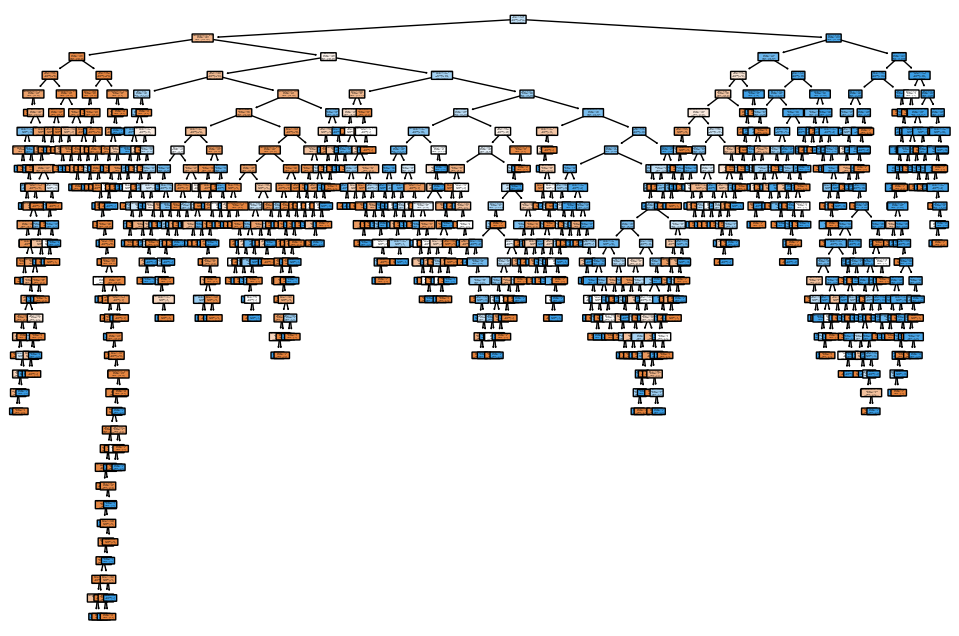

In [70]:
plt.figure(figsize=(12,8))
plot_tree(model_tree,
          feature_names=list(X_train.columns),
          class_names=['No Oximetry','Oximetry'],
          filled=True,
          rounded=True)
plt.show()

In the visualization, it is difficult to interpet what is happening as we can't see what represents each node. We can see that the tree is deep and there are branches which are deeper than others. We are going to print the rules to understand it better.

In [71]:
tree_rules = export_text(model_tree, feature_names=list(X_train.columns))
print(tree_rules)

|--- EtCO₂ <= 0.05
|   |--- Skin Temperature <= -0.39
|   |   |--- BP <= 0.14
|   |   |   |--- RR <= -0.67
|   |   |   |   |--- Skin Temperature <= -0.85
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Skin Temperature >  -0.85
|   |   |   |   |   |--- BP <= -0.93
|   |   |   |   |   |   |--- Skin Temperature <= -0.73
|   |   |   |   |   |   |   |--- Skin Temperature <= -0.82
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- Skin Temperature >  -0.82
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- Skin Temperature >  -0.73
|   |   |   |   |   |   |   |--- FiO₂ <= 1.14
|   |   |   |   |   |   |   |   |--- BP <= -1.57
|   |   |   |   |   |   |   |   |   |--- BP <= -1.60
|   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |   |--- BP >  -1.60
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |--- BP >  -1.57
|   |   |   |   |   |   |   |   |   |--- class: 1


Here we can see the upper splits of our data. The first split separated the data which has ETCO2 >= 0.05 from the other. At the nexts levels splits we can see also ETCO2 and also Skin Temperature. This are the trehsolds which have maximized the criteria in this Decision Tree. This is interesting to see because it makes sense seeing the Logistic Regression Rules. In this case ETCO2 and Skin Temperature are the ones which contribute the most or are more important for the decision, and it happens the same in logistic regression because those features are the ones with have higher coeficients.

Now we are going to see the rules from the prunned tree to see the comparation.

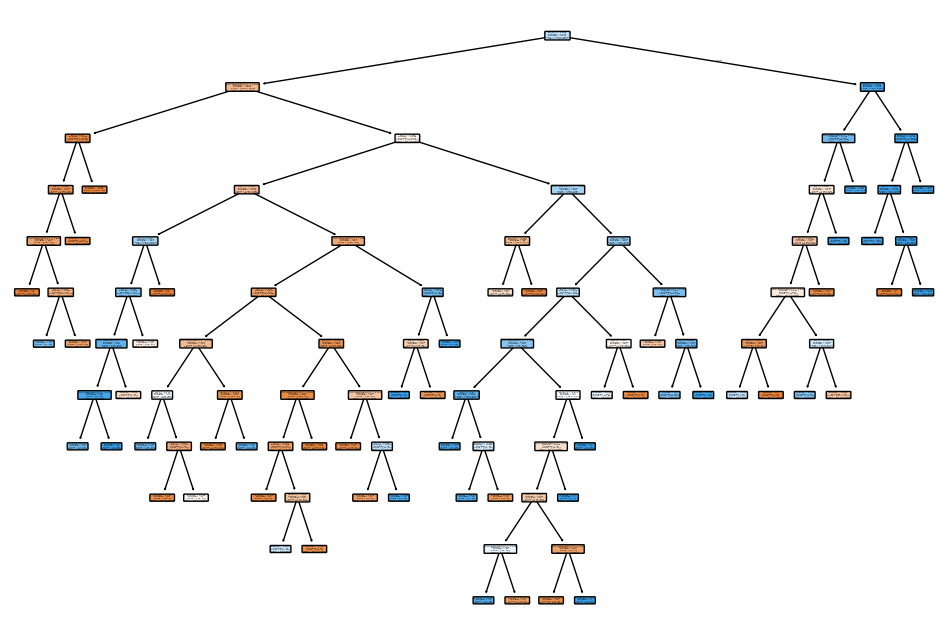

In [72]:
plt.figure(figsize=(12,8))
plot_tree(model_pruned,
          feature_names=list(X_train.columns),
          class_names=['No Oximetry','Oximetry'],
          filled=True,
          rounded=True)
plt.show()

This time it keeps being non interpretable but we can see better its structure. The maximum depth of this tree is 11, which is greater than the one in ID3 classifier. it is interesting to see the prunning, because it is clear that some parts have been removed and prunned, and this has helped a lot with generalization. We are going to see the printed rules.

In [73]:
pruned_rules = export_text(model_pruned, feature_names=list(X_train.columns))
print(pruned_rules)

|--- EtCO₂ <= 0.05
|   |--- Skin Temperature <= -0.39
|   |   |--- BP <= 0.14
|   |   |   |--- RR <= -0.67
|   |   |   |   |--- Skin Temperature <= -0.85
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Skin Temperature >  -0.85
|   |   |   |   |   |--- BP <= -0.93
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- BP >  -0.93
|   |   |   |   |   |   |--- class: 0
|   |   |   |--- RR >  -0.67
|   |   |   |   |--- class: 0
|   |   |--- BP >  0.14
|   |   |   |--- class: 0
|   |--- Skin Temperature >  -0.39
|   |   |--- RR <= -0.36
|   |   |   |--- FiO₂ <= -0.73
|   |   |   |   |--- BP <= 0.23
|   |   |   |   |   |--- BP <= -0.31
|   |   |   |   |   |   |--- Skin Temperature <= 0.94
|   |   |   |   |   |   |   |--- Skin Temperature <= -0.12
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- Skin Temperature >  -0.12
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- Skin Temperature >  0.94
|   |   |   |   |   |   |   

We can see that upper splits are the same, so it keeps being the same tree but now it is simplificated so it does not overfit.

# C, E

In this section we are going to compare the results of the two models with ID3 and give the final evaluation results using accuracy, precision, recall and f1.

Our first comparation in results is the sizes of the trees. While the best ID3 has depth of 7, the best Decision Tree founf adter prunning has depth 11. Both cases did not overfit so it is interesting to see how we achieved good results with relatively deep (not much) trees.
Now we are going to present the results and explain them.

In [74]:
print(f"Val — Accuracy: {acc_val_ID3:.3f}, Precision: {prec_val_ID3:.3f}, Recall: {rec_val_ID3:.3f}, F1: {f1_val_ID3:.3f}")
print(f"Val — Accuracy: {acc_val_tree:.3f}, Precision: {prec_val_tree:.3f}, Recall: {rec_val_tree:.3f}, F1: {f1_val_tree:.3f}")
print(f"Val — Accuracy: {acc_val_logreg:.3f}, Precision: {prec_val_logreg:.3f}, Recall: {rec_val_logreg:.3f}, F1: {f1_val_logreg:.3f}")

Val — Accuracy: 0.875, Precision: 0.868, Recall: 0.932, F1: 0.899
Val — Accuracy: 0.903, Precision: 0.905, Recall: 0.935, F1: 0.920
Val — Accuracy: 0.855, Precision: 0.877, Recall: 0.879, F1: 0.878


At first sight, we can see how generally we obtain the best results with Decision Tree, followed by the ID3 classifier and leaving logistic regression for the last position. However, we'll inspect carefully each metric.

We'll first begin by commenting the metrics which do not explain well our performance:
- Accuracy: Decision trees are better in this metric. The fact that the decision tree found maximized this metric helps a lot. Logistic Regression is last and ID3 falls in between. However, this metric does not helps us because it does not penalize False Negatives.
- Precision: It is interesting to see that Logistic Regression has btter precision than ID3 in this case. This means it penalizes better true positives, which is not the thing we want to do here. So, although Logistic Regression is better in this metric, it does not mean that the model is better for our case.
- F1: Decision Tree is better by a large margin. We don't want to use this metric as uses both precision and recall the same way, even though it helps with imbalance.

Now we are going to compare our representative metric: Recall.
- Recall: We can se hee how ID3 and Decision Tree are not that far away in this metric. This means that the two type of models are not that apart in this specific project.

As a conclusion, we can say that at the moment, Tree-Base models are the best option for this type of project as it seems to benefit more form our data basing on its form and strucure after the preprocessing. On the other side, non-tree models have gotten the worse results.

In specific, Decision Tree hase achieved the best results at the moment, with its 0.939 in the recall metric, after we have prunned it. The post prunning was very beneficial to avoid overfitting and was the key factor to obatin the best results. This result is followed closely by the ID3 classifier, with 0.932 recall. This model also gives a very good result by penalizing well False Negatives using its tree-based structure. Finally, logistic regression falls to last with its 0.879 recall metric.

Another finding is that simpler models has given better results. We can see this because, in order to achieve the best results, we have need to regularizate carefully, by prunning the Decision Tree or by controlling max_depth in ID3.

As a final comment for ID3 comparation, we can se how its behaviour and results are most similar to regularized Decision Trees than logistic regression, whicch it is normal because it is a very simple tree, like the one achived with Decision Trees afetr prunning. That's why its results are more similar to Decision Trees than Logistic Regression.

All this results have to be read taking into account these are the first models we fit and we have to perform all the hyperparmeter tunning and ensamles, so later we may find out conclusions with differ form the ones above.

## 3.3

# A

In this section, we selected the Decision Tree as the core model for hyperparameter optimization. This choice was motivated by its strong performance in previous sections and the fact that it is highly sensitive to changes in hyperparameters, which makes tuning very impactful.

We performed a grid search using 7-fold cross-validation, optimizing specifically for Recall, since this is the primary evaluation metric in our project. The following hyperparameters were tuned:
- criterion: {gini, entropy}
- max_depth: {3, 5, 7, 9, 11, None}
- min_samples_split: {2, 5, 10, 20}
- min_samples_leaf: {1, 2, 4, 6}
- ccp_alpha: {0.0, 0.0005, 0.001, 0.005}

In [75]:
params = {
    "criterion": ["entropy", "gini"],
    "max_depth": [3, 5, 7, 9, 11, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 6],
    "ccp_alpha": [0.0, 0.0005, 0.001, 0.005]
}

tree = DecisionTreeClassifier(random_state=0)

grid = GridSearchCV(
    estimator=tree,
    param_grid=params,
    scoring="recall", 
    cv=7,
    n_jobs=-1
)

grid.fit(Xtr, ytr)

best_tree = grid.best_estimator_
grid.best_params_, grid.best_score_


({'ccp_alpha': 0.0005,
  'criterion': 'entropy',
  'max_depth': 11,
  'min_samples_leaf': 6,
  'min_samples_split': 20},
 np.float64(0.9240643253767938))

The selected hyperparameters suggest a model that:
- deeper trees (max_depth=11)
- stronger regularization (min_samples_split=20, min_samples_leaf=6)
- and benefits from light cost-complexity pruning (ccp_alpha=0.0005).
The cross-validated recall may be slightly lower than in the first Decision Tree because cross-validation evaluates the model more strictly.

# B

In this section, we experiment with several ensemble methods built on top of decision-tree-based learners. The purpose is to improve the model's performance while avoiding underfitting, and to determine whether combining multiple weak or strong learners can outperform the tuned single Decision Tree from part A.

We evaluate four ensemble methods: Random Forest, Gradient Boosting, AdaBoost, and Extra Trees. All models are trained on the same training set and evaluated primarily using Recall, which remains the key metric in our project.

In [76]:
models = {}

models["Random Forest"] = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=20,
    min_samples_leaf=6,
    criterion="entropy",
    random_state=0
)

models["Gradient Boosting"] = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=0
)

models["AdaBoost"] = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=300,
    learning_rate=0.5,
    random_state=0
)

models["Extra Trees"] = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=20,
    min_samples_leaf=6,
    criterion="entropy",
    random_state=0
)

results = []

for name, model in models.items():
    model.fit(Xtr, ytr)
    y_pred = model.predict(Xv)

    acc = metrics.accuracy_score(yv, y_pred)
    prec = metrics.precision_score(yv, y_pred, zero_division=0)
    rec = metrics.recall_score(yv, y_pred, zero_division=0)
    f1 = metrics.f1_score(yv, y_pred, zero_division=0)

    print(f"{name} — Accuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}")

    results.append([name, acc, prec, rec, f1])

df_results = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1"])
df_results


Random Forest — Accuracy: 0.916, Precision: 0.923, Recall: 0.937, F1: 0.930
Gradient Boosting — Accuracy: 0.904, Precision: 0.917, Recall: 0.922, F1: 0.919
AdaBoost — Accuracy: 0.881, Precision: 0.900, Recall: 0.901, F1: 0.900
Extra Trees — Accuracy: 0.914, Precision: 0.922, Recall: 0.934, F1: 0.928


,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.916367,0.923249,0.937216,0.930180
1,Gradient Boosting,0.903777,0.916541,0.922088,0.919306
2,AdaBoost,0.881295,0.899547,0.900908,0.900227
3,Extra Trees,0.913669,0.921642,0.934191,0.927874


The ensemble experiments demonstrated that combining multiple tree-based learners can significantly improve the performance compared to a single Decision Tree. Among the four tested ensemble methods, Random Forest, Gradient Boosting, AdaBoost, and Extra Trees, the best results were achieved by Random Forest and Extra Trees, both of which showed the strongest Recall values on the validation set.

Overall, the ensemble results confirm that tree-based ensembles outperform individual models and offer better generalization, stability, and robustness.


# C

To evaluate the stability and generalization ability of the best-performing ensemble models, we applied 7-fold cross-validation on the training set. We selected the two strongest models from part B — Random Forest and Extra Trees — both of which achieved the highest Recall values on the validation set.

In [77]:
cv_rf = cross_val_score(models["Random Forest"], Xtr, ytr, scoring="recall", cv=7)
cv_ext = cross_val_score(models["Extra Trees"], Xtr, ytr, scoring="recall", cv=7)

print(cv_rf.mean(), cv_rf.std())
print(cv_ext.mean(), cv_ext.std())

0.9369375023926596 0.007837282654071093
0.9260901847979083 0.011386786597207908


Both ensemble models show high and stable recall, with very low standard deviation across folds. 
The Random Forest achieves the highest cross-validated recall (0.9366), while Extra Trees performs only slightly worse (0.9269).
The low variance (around 0.008–0.011) indicates that the models generalize consistently and are not dependent on a particular subset of the training data.

# D

In [ ]:
rf = models["Random Forest"]
rf.fit(Xtr, ytr)

train_pred = rf.predict(Xtr)
val_pred   = rf.predict(Xv)

cv_scores = cross_val_score(rf, Xtr, ytr, scoring="recall", cv=7)
mean = cv_scores.mean()
std = cv_scores.std()

print("Training Metrics:")

acc_train = metrics.accuracy_score(ytr, train_pred)
prec_train = metrics.precision_score(ytr, train_pred)
rec_train = metrics.recall_score(ytr, train_pred)
f1_train = metrics.f1_score(ytr, train_pred)

print(f"Accuracy: {acc_train:.4f}")
print(f"Precision: {prec_train:.4f}")
print(f"Recall: {rec_train:.4f}")
print(f"F1 Score: {f1_train:.4f}")

print("\nValidation Metrics:")
acc_val = metrics.accuracy_score(yv, val_pred)
prec_val = metrics.precision_score(yv, val_pred)
rec_val = metrics.recall_score(yv, val_pred)
f1_val = metrics.f1_score(yv, val_pred)

print(f"Accuracy: {acc_val:.4f}")
print(f"Precision: {prec_val:.4f}")
print(f"Recall: {rec_val:.4f}")
print(f"F1 Score: {f1_val:.4f}")

print("\nCross-Validation Stability:")

print(f"Mean Recall: {mean:.4f}")
print(f"Standard deviation: {std:.4f}")


To confirm that the final model generalizes well and does not suffer from overfitting, we evaluated its performance on the training set, validation set, and using 7-fold cross-validation. The best-performing model from parts B and C was the Random Forest classifier, so all evaluations in this section focus on this model.

The training metrics are only slightly higher than the validation metrics (differences around 0.02–0.03), which is expected in a well-generalizing ensemble model.
If the model were overfitting, we would observe a much larger drop when moving from the training set to the validation set.
Here, the performance remains consistent, indicating that the model is not memorizing the training data.

## 3.4 Evaluation of the Impact of the Chosen Strategy for Solving the Classification Task

# A

The preprocessing strategy focused on cleaning and preparing the observation dataset, which contained physiological measurements for predicting oximetry states. Initial steps included loading the data from patient, station, and observation files, but only the observation file was used for modeling due to its direct relevance. Outliers were removed using the IQR method on columns with low outlier percentages, such as SpO₂, PI, RR, and others, to reduce noise without excessive data loss. The dataset was then split into training, validation, and test sets using a 60/20/20 ratio with stratification to maintain class balance in the binary oximetry target. No imputation was needed as there were no missing values, and all features were numeric (float64), making the data ML-ready. 

# B

Data transformations were evaluated by combining scaling methods (none, StandardScaler, MinMaxScaler) with distribution transformers (none, PowerTransformer with Yeo-Johnson, QuantileTransformer to normal). Combinations were tested using Logistic Regression pipelines on the training set, sorted by F1 score to account for mild class imbalance. The best combination was StandardScaler followed by PowerTransformer, as it normalized ranges, reduced skewness (especially in variables like CO), and centered data around mean 0 and std 1. This improved model sensitivity to features, particularly for algorithms like Logistic Regression and tree-based models, leading to better generalization without overcomplicating the process.

# C

Attribute selection used multiple methods: Mutual Information for relevance ranking, ANOVA F-score/P-value for statistical differences between classes, and wrapper methods (RFE, SFS, SBS with RandomForest) for iterative refinement. Latitude and longitude were dropped as irrelevant (zero mutual info, high P-values), and the final features were RR, EtCO₂, FiO₂, BP, and Skin Temperature, which consistently ranked highest across methods. PCA was tested but not used, as it offered no performance gain and reduced interpretability.
Algorithms included a custom ID3 classifier (tree-based, information gain), DecisionTree (entropy criterion, post-pruned), and LogisticRegression (non-tree baseline). Tree-based models outperformed the non-tree one due to the data's structure post-preprocessing. Hyperparameter tuning via GridSearchCV optimized recall, focusing on max_depth, min_samples_split/leaf, criterion, and ccp_alpha for DecisionTree. Ensembles (RandomForest, GradientBoosting, AdaBoost, ExtraTrees) were built on tree learners with parameters like n_estimators=300 and regularization to boost stability. RandomForest and ExtraTrees excelled, combining weak learners for better generalization and reduced variance compared to single trees.

# D

The best model for deployment is the tuned RandomForest ensemble, as it achieved the strongest performance across metrics, particularly recall, while showing stability in cross-validation (low std deviation). It generalizes well without overfitting, handles the dataset's mild imbalance effectively.

# E

The deployment pipeline starts with loading new observation data, dropping irrelevant columns (e.g., latitude, longitude), and selecting the key features (RR, EtCO₂, FiO₂, BP, Skin Temperature). Apply the saved preprocessing steps: StandardScaler for centering/scaling, followed by PowerTransformer (Yeo-Johnson) for normalization. The tuned RandomForest model then predicts oximetry states, outputting probabilities for thresholding if needed. In a production environment, the pipeline should also include monitoring of input feature distributions to detect data drift, scheduled model performance checks, and periodic retraining if significant deviations occur. This ensures replicability, handles similar input distributions, and maintains performance without retraining from scratch.

participation 

Michal Fajer: 50%
Adrian Quirante González: 50%